-----

------

A continuacion se implementan la base de datos otorgada por la empresa Ice que vende video juegos', con una muestra de los valores que contiene y la informacion base.'

In [2]:
import pandas as pd

ice_games = pd.read_csv('/datasets/games.csv')
ice_games.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [3]:
ice_games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


#La base de datos sera revisada a continuacion, verificando si hay valores duplicados y ausentes antes de cambiar el tipo de valor de las columnas
#'User_Score' y 'Rating', ya que son de tipo object lo cual nos impediria los analisis estadisticos, lo mismo que ocurre con 'Year_of_Release', que creo es mejor sea de tipo int para evitar errores. Asi mismo se realizara un cambio de nombres de las columnas a letras minusculas para tener mas claridad.
#Primero se realizara la revision de duplicados y luego de ausentes para corregir esto en la base de datos.
#Por ultimo los valores nulos de las columnas de score necesitan ser cambiados por que van a dificultar el analisis estadistico.

In [5]:
ice_games.columns = ice_games.columns.str.strip().str.lower().str.replace(' ', '_')
ice_games.head()

#Reemplazar los nombres de las columnas

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [6]:
import numpy as np

ice_games['user_score'] = ice_games['user_score'].replace('tbd', np.nan)

ice_games['user_score'] = ice_games['user_score'].astype(float)

ice_games.info()
#Conversion y manejo de datos de la columna user_score

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   object 
dtypes: float64(7), object(4)
memory usage: 1.4+ MB


In [7]:
ice_games = ice_games.dropna(subset=['year_of_release'])
ice_games['year_of_release'] = ice_games['year_of_release'].astype(int)

ice_games.head()
#Conversion de los datos

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [8]:
ice_games.duplicated().sum()

0

In [9]:
ice_games.isnull().sum()

#Valores Ausentes o Faltantes

name                  2
platform              0
year_of_release       0
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8463
user_score         8983
rating             6678
dtype: int64

In [10]:
ice_games = ice_games.dropna(subset=['name', 'genre'])

print(ice_games[['name', 'genre']].isnull().sum())

name     0
genre    0
dtype: int64


En el caso de los datos ausentes en las columna 'critic_score', 'user_score' y 'rating' creo que gran parte debe encontrarse en los años de lanzamiento
mas antiguo.
Ademas, para el analisis correspondiente, al ser un enfoque para promociones y marketing de 2017, es recomendable depurar los lanzamientos
que se encuentren antes del año 2000.

In [11]:
ice_games['year_of_release'].value_counts()

2008    1427
2009    1426
2010    1255
2007    1197
2011    1136
2006    1006
2005     939
2002     829
2003     775
2004     762
2012     653
2015     606
2014     581
2013     544
2016     502
2001     482
1998     379
2000     350
1999     338
1997     289
1996     263
1995     219
1994     121
1993      60
1981      46
1992      43
1991      41
1982      36
1986      21
1983      17
1989      17
1990      16
1987      16
1988      15
1985      14
1984      14
1980       9
Name: year_of_release, dtype: int64

In [12]:
ice_games_2000 = ice_games[ice_games['year_of_release'] >= 2000]

print(ice_games_2000.shape)

(14470, 11)


In [13]:
ice_games_2000.isnull().sum()

name                  0
platform              0
year_of_release       0
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       6583
user_score         7099
rating             4807
dtype: int64

In [14]:
ice_games_2000 = ice_games[ice_games['year_of_release']>= 2000].copy()

ice_games_2000['global_sales'] = (ice_games_2000['na_sales'] + ice_games_2000['eu_sales'] + ice_games_2000['jp_sales'] + ice_games_2000['other_sales'])

ice_games_2000.head()

#Calculo de las ventas totales para cada juego en todas las regiones

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,global_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
6,New Super Mario Bros.,DS,2006,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E,29.80
7,Wii Play,Wii,2006,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E,28.91


In [15]:
ice_top_7 = ice_games_2000.sort_values(by = 'global_sales', ascending = False)

ice_top_7.head(7)
# Historial de los juegos mas vendidos

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,global_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
6,New Super Mario Bros.,DS,2006,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E,29.80
7,Wii Play,Wii,2006,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E,28.91
8,New Super Mario Bros. Wii,Wii,2009,Platform,14.44,6.94,4.70,2.24,87.0,8.4,E,28.32
10,Nintendogs,DS,2005,Simulation,9.05,10.95,1.93,2.74,NaN,NaN,NaN,24.67


#Con los resultados obtenidos, ya los datos estan preparados adecuadamente para su Analisis. A continuacion:

In [17]:
games_by_year = ice_games['year_of_release'].value_counts().sort_index(ascending=False)

print(games_by_year)

#Cuantos juegos fueron lanzados en diferentes años.

#Los años de lanzamiento son significativos por que el resultado esperado es una proyeccion respecto al siguiente año
#Considero que los datos de lanzamientos con mucho tiempo de diferencia van a crear una burbuja de errores en las proyecciones
#y un margen y probabilidad de error bastante grande que no se vera en los resultados emitidos pero si en la realidad. 

2016     502
2015     606
2014     581
2013     544
2012     653
2011    1136
2010    1255
2009    1426
2008    1427
2007    1197
2006    1006
2005     939
2004     762
2003     775
2002     829
2001     482
2000     350
1999     338
1998     379
1997     289
1996     263
1995     219
1994     121
1993      60
1992      43
1991      41
1990      16
1989      17
1988      15
1987      16
1986      21
1985      14
1984      14
1983      17
1982      36
1981      46
1980       9
Name: year_of_release, dtype: int64


In [18]:
games_until_1999 = (ice_games['year_of_release'] <= 1999).sum()

total_since_2000 = (ice_games['year_of_release'] >= 2000).sum()

print(f'El total de juegos lanzados hasta 1999 fueron de: {games_until_1999}')
print(f'El total de juegos lanzados desde el 2000 hasta 2016 fueron de: {total_since_2000}')

El total de juegos lanzados hasta 1999 fueron de: 1974
El total de juegos lanzados desde el 2000 hasta 2016 fueron de: 14470


#Con este ultimo dato, podemos observar que la cantidad de juegos lanzados a partir del 2000 han sido 10 veces mas que los previos,
# por ende se valida que es necesario quitarlos ya que perjudicaria al analisis para construir el modelo para 2017.
# A continuacion se realizara un analisis de la evolucion y comportamiento de las plataformas.

In [20]:
ice_games['global_sales'] = (ice_games['na_sales']+ice_games['eu_sales']+ice_games['jp_sales']
                            +ice_games['other_sales'])

platform_sales = (ice_games.groupby(['platform', 'year_of_release'])['global_sales'].sum().reset_index())
    
platform_sales.head(10)

#Variacion de ventas de una plataforma a otra

,platform,year_of_release,global_sales
0,2600,1980,11.38
1,2600,1981,35.68
2,2600,1982,28.88
3,2600,1983,5.84
4,2600,1984,0.27
5,2600,1985,0.45
6,2600,1986,0.67
7,2600,1987,1.94
8,2600,1988,0.74
9,2600,1989,0.63


In [21]:
top_platforms =(ice_games.groupby('platform')['global_sales']).sum().sort_values(ascending=False).head(5)

print(f'Las 5 plataformas mas exitosas de todo el periodo presentado por la muestra son: {top_platforms}')

Las 5 plataformas mas exitosas de todo el periodo presentado por la muestra son: platform
PS2     1233.56
X360     961.24
PS3      931.34
Wii      891.18
DS       802.78
Name: global_sales, dtype: float64


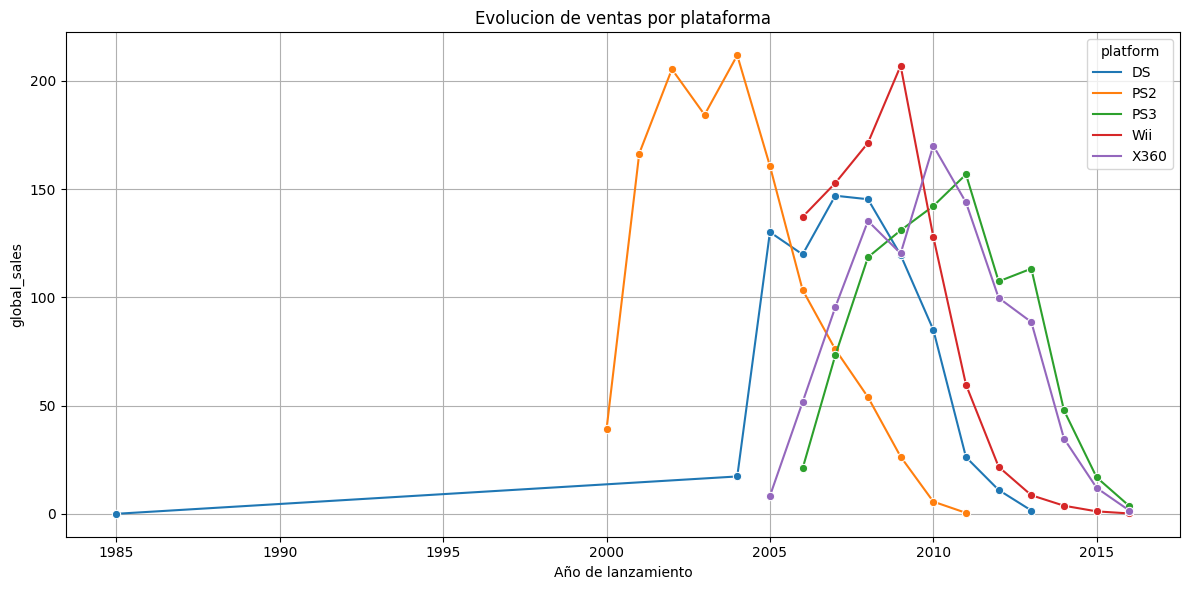

In [22]:
platforms_all = top_platforms.index.tolist()

sales_all_plat = platform_sales[platform_sales['platform'].isin(platforms_all)]

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.lineplot(data=sales_all_plat, x='year_of_release', y='global_sales', hue='platform', marker='o')

plt.title('Evolucion de ventas por plataforma')
plt.xlabel('Año de lanzamiento')
plt.grid(True)
plt.tight_layout()
plt.show()

# En este grafico podemos observar el fuerte ascenso de las plataformas en la decada del 2000-2010 para su caida en picada a partir de ese año.
# y solo nos referimos a las plataformas que aun estan en el mercado.

In [24]:
last_years = ice_games.groupby('platform')['year_of_release'].max().sort_values(ascending=False)
print(last_years.head(10))
print(last_years.tail(10))

#Esta lista de datos muestra el ultimo año que cada plataforma registro ventas. Siendo las 10 de arriba las que aun permanecen en el mercado y 
# las ultimas las que ya cerraron oferta y no compiten mas.

platform
XOne    2016
3DS     2016
X360    2016
WiiU    2016
Wii     2016
PSV     2016
PC      2016
PS4     2016
PS3     2016
PSP     2015
Name: year_of_release, dtype: int64
platform
SNES    1999
PCFX    1996
NG      1996
3DO     1995
TG16    1995
NES     1994
SCD     1994
GEN     1994
GG      1992
2600    1989
Name: year_of_release, dtype: int64


In [25]:
perspectiva_de_vida = ice_games.groupby('platform')['year_of_release'].agg(['min', 'max'])
perspectiva_de_vida['duracion'] = perspectiva_de_vida['max'] - perspectiva_de_vida['min']
perspectiva_de_vida = perspectiva_de_vida.sort_values(by='duracion', ascending=False)

print(perspectiva_de_vida)

#Con estos datos se puede observar que la creacion de una nueva plataforma es poco probable debido al alto riesgo que representa.
#Asi mismo, las perspectivas para las plataformas con mas duracion estara basada en la fidelidad de sus usuarios y el impacto que puedan crear para atraer
#nuevos usuarios. Las tendencias sociales nos dicen que los padres comparten mas este tipo de actividades con sus hijos, por ende al crear perspectivas de 
#entretenimiento infantil puede que sea una buena pauta para los desarrolladores.

           min   max  duracion
platform                      
PC        1985  2016        31
DS        1985  2013        28
GB        1988  2001        13
X360      2005  2016        11
PSP       2004  2015        11
PS2       2000  2011        11
NES       1983  1994        11
DC        1998  2008        10
Wii       2006  2016        10
PS3       2006  2016        10
2600      1980  1989         9
SNES      1990  1999         9
PS        1994  2003         9
XB        2000  2008         8
GBA       2000  2007         7
GC        2001  2007         6
N64       1996  2002         6
3DS       2011  2016         5
PSV       2011  2016         5
SAT       1994  1999         5
WiiU      2012  2016         4
GEN       1990  1994         4
NG        1993  1996         3
XOne      2013  2016         3
PS4       2013  2016         3
WS        1999  2001         2
3DO       1994  1995         1
SCD       1993  1994         1
TG16      1995  1995         0
PCFX      1996  1996         0
GG      

# Vamos a realizar los siguientes analisis en base al movimiento a partir del año 2000 al 2016.
# Las plataformas potencialmente rentables, comportamientos de los juegos segun genero y su consumo en mas de una plataforma.

In [27]:
platform_sales = ice_games_2000.groupby('platform')['global_sales'].sum().sort_values(ascending=False)

platform_sales.head()

#Las plataformas con mayores ventas globales. Los primeros lugares son para PS2-3, X360 y Wii.

platform
PS2     1233.56
X360     961.24
PS3      931.34
Wii      891.18
DS       802.76
Name: global_sales, dtype: float64

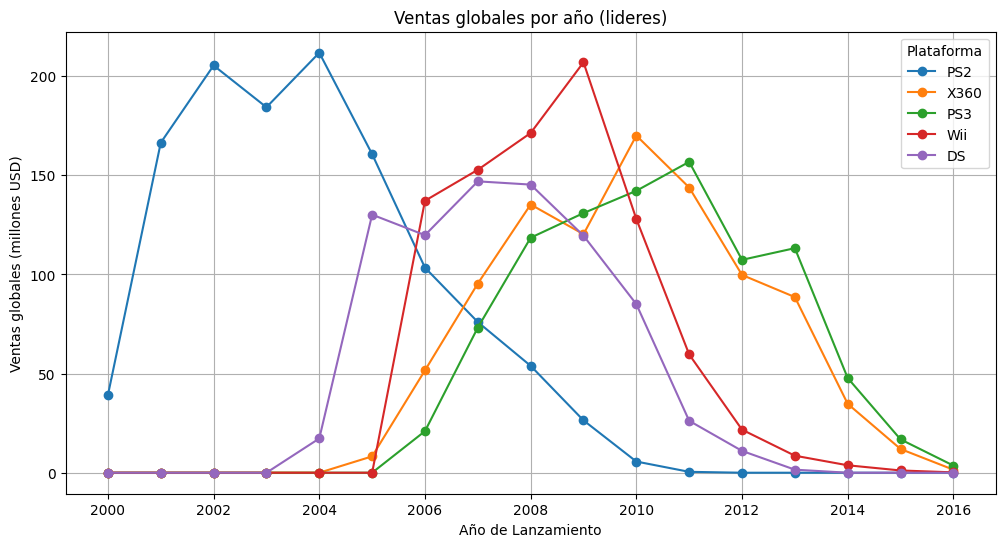

In [28]:
import matplotlib.pyplot as plt

anual_sales = ice_games_2000.groupby(['year_of_release', 'platform'])['global_sales'].sum().unstack().fillna(0)

top_platforms = platform_sales.head(5).index
anual_sales[top_platforms].plot(figsize=(12,6), marker='o')
plt.title('Ventas globales por año (lideres)')
plt.xlabel('Año de Lanzamiento')
plt.ylabel('Ventas globales (millones USD)')
plt.legend(title='Plataforma')
plt.grid(True)
plt.show()


#En esta grafica podemos observar que PS2 tuvo un crecimiento fuerte entre 2000 y 2001 mientras que las otras plataformas sus crecimientos fueron entre 2005 hasta 2010.
#Podemos observar que luego en su mayoria han tenido declives fuertes sin comportamientos de ascensos o recuperaciones.
#La tendencia indica que si bien se observan declives, las plataformas aun estables son PS3, Wii y X360.


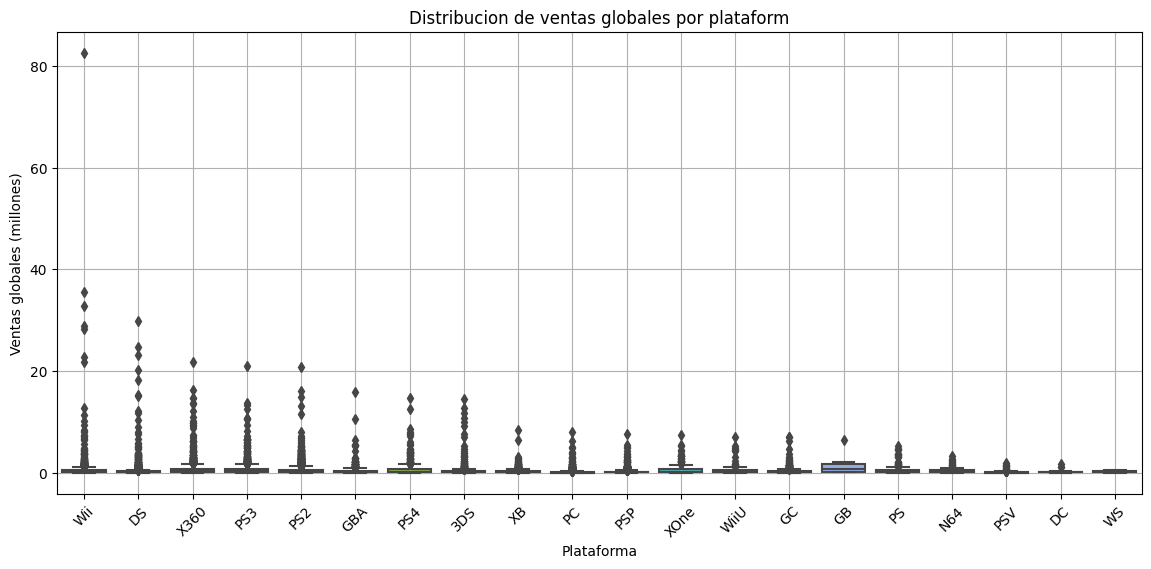

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))
sns.boxplot(data=ice_games_2000, x='platform', y='global_sales')
plt.title('Distribucion de ventas globales por plataform')
plt.xlabel('Plataforma')
plt.ylabel('Ventas globales (millones)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

#Diagrama de caja para las ventas globales de todos los juegos.

# Hay diferencias entre las plataformas por la cantidad de juegos y el exito de los mismos, sin embargo la media de ventas es baja en muchas plataformas
# porque son pocos los juegos los que obtienen ventas extremadamente altas, son excepciones.


In [32]:
wii_games = ice_games_2000[ice_games_2000['platform'] == 'Wii']
wii_games = wii_games.dropna(subset=['user_score', 'critic_score', 'global_sales'])

wii_games.head(3)

#Afectacion de las reseñas de usuarios y profesionales a las ventas en la plataforma wii

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,global_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))

plt.subplot(1, 2, 1)
sns.scatterplot(data=wii_games, x='critic_score', y='global_sales')
plt.title('Ventas segun reseña de criticos (Wii)')
plt.xlabel('Puntaje de criticos')
plt.ylabel('Ventas globales (millones USD)')

plt.subplot(1, 2, 2)
sns.scatterplot(data=wii_games, x-'user_score', y='global_sales')
plt.title('Ventas segun reseña de usuarios (Wii)')
plt.xlabel('Puntaje de usuarios')
plt.ylabel('Ventas globales (millones USD)')

plt.tight_layout()
plt.show()

SyntaxError: positional argument follows keyword argument (1527049097.py, line 13)

In [34]:
cor_critic = wii_games['critic_score'].corr(wii_games['global_sales'])
cor_user = wii_games['user_score'].corr(wii_games['global_sales'])

print(f'La correlacion de ventas para Wii segun las reseña de los criticos es: {cor_critic:.2f}')
print(f'La correlacion de ventas para Wii segun la reseña de los usuarios es: {cor_user:.2f}')

#Correlaciones

La correlacion de ventas para Wii segun las reseña de los criticos es: 0.17
La correlacion de ventas para Wii segun la reseña de los usuarios es: 0.11


Las correlaciones tanto de criticos como de usuarios sobre la plataforma son debiles, por ende podemos decir que las criticas no son influyentes 
o al menos no de manera fuerte sobre las ventas.
Puede deberse a que los criticos dieron una calificacion negativa y sin embargo los usuarios si hicieron la compra pero no reflejaron su opinion y por ende no afecto a las ventas.

In [36]:
multi_platform_games = ice_games_2000.groupby('name')['platform'].nunique()
multi_platform_games = multi_platform_games[multi_platform_games > 1].index

#print(multi_platform_games)

multi_games = ice_games_2000[ice_games_2000['name'].isin(multi_platform_games)]
print(multi_games)

# Ventas de los juegos multiplataformas

                                                   name platform  \
16                                   Grand Theft Auto V      PS3   
17                        Grand Theft Auto: San Andreas      PS2   
23                                   Grand Theft Auto V     X360   
24                          Grand Theft Auto: Vice City      PS2   
29                       Call of Duty: Modern Warfare 3     X360   
...                                                 ...      ...   
16706                     Men in Black II: Alien Escape       GC   
16709  SCORE International Baja 1000: The Official Game      PS2   
16710                     Samurai Warriors: Sanada Maru      PS3   
16713                                  Spirits & Spells      GBA   
16714                               Winning Post 8 2016      PSV   

       year_of_release       genre  na_sales  eu_sales  jp_sales  other_sales  \
16                2013      Action      7.02      9.09      0.98         3.96   
17                200

In [37]:
ventas_por_juego = multi_games.groupby(['name', 'platform'])['global_sales'].sum().unstack().fillna(0)

best_platform = ventas_por_juego.idxmax(axis=1)
mayores_ventas = ventas_por_juego.max(axis=1)

top_multigames = pd.DataFrame({'best_platform': best_platform, 'max_sales': mayores_ventas})

top_multigames.head(5)

,best_platform,max_sales
name,,
Frozen: Olaf's Quest,3DS,0.59
007: Quantum of Solace,X360,1.48
007: The World is not Enough,N64,1.56
11eyes: CrossOver,PSP,0.02
18 Wheeler: American Pro Trucker,PS2,0.40


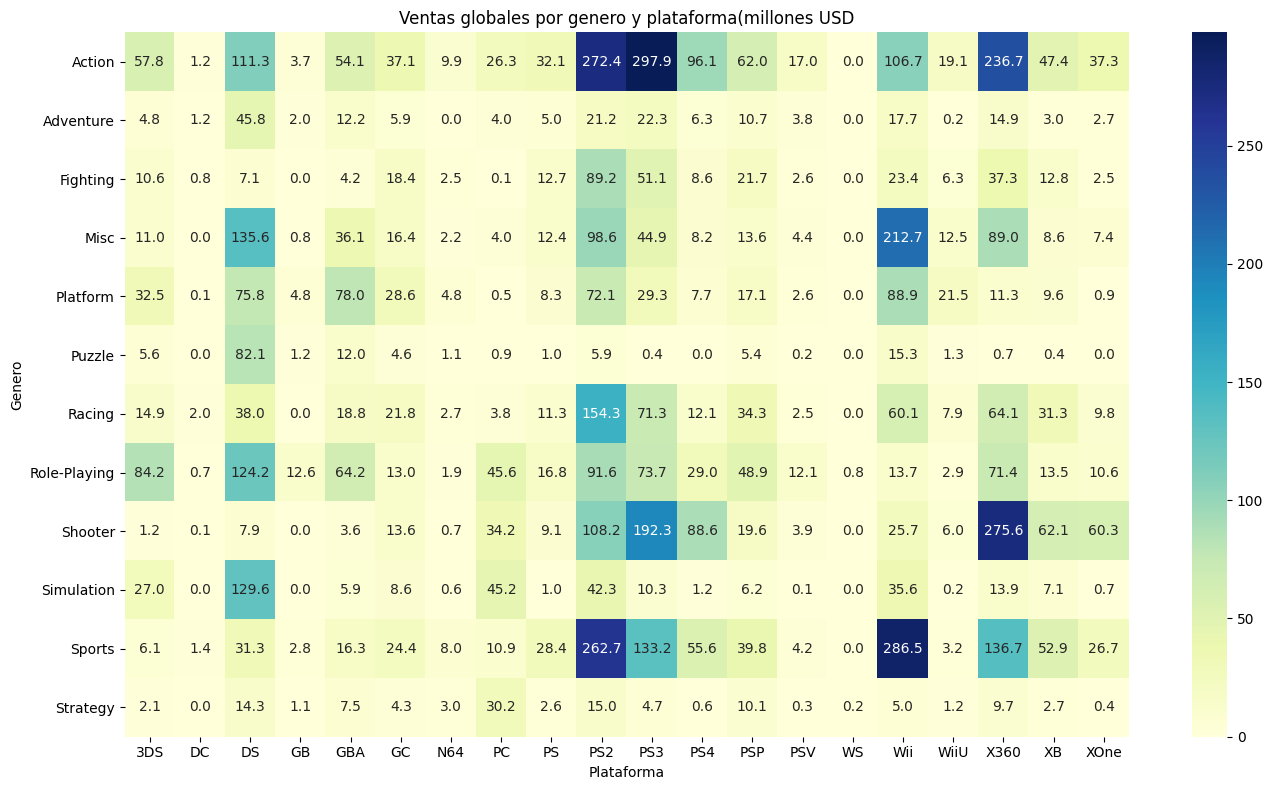

In [38]:
ventas_por_genero = (ice_games_2000.groupby(['platform', 'genre'])['global_sales'].sum().reset_index())

import seaborn as sns
import matplotlib.pyplot as plt

pivot_data = ventas_por_genero.pivot(index='genre', columns='platform', values='global_sales').fillna(0)
plt.figure(figsize=(14,8))
sns.heatmap(pivot_data, annot=True, fmt='.1f', cmap='YlGnBu')
plt.title('Ventas globales por genero y plataforma(millones USD')
plt.xlabel('Plataforma')
plt.ylabel('Genero')
plt.tight_layout()
plt.show()
#Comportamiento de las ventas por genero. Cual genero es el mas rentable?

Los generos que son mas atractivos para los usuarios son los de accion, deportes y belicos(shooter, simulations) basados en que las plataformas
con las principales ventas y/o hits tienen su hallazgo en estos generos. Supongo que debe depender mucho del tipo de plataforma y cuan comoda sea para el
usuario y la facilidad que tiene el mismo para hacer inmersion en el juego. Puede que uno de los puntos fuertes de inversion sean hacer mas realista la inmersion y mas comodo y adaptable la imagen del juego asi como universos alternos, ya que creo que esa adaptabilidad al usuario ha sido lo que ha generado mayor popularidad en ciertas plataformas para el mismo juego.

In [39]:
sales_by_platform_region = (ice_games_2000.groupby('platform')[['na_sales', 'eu_sales', "jp_sales"]].sum())

sales_by_platform_region['total'] = sales_by_platform_region.sum(axis=1)
top5_platforms = sales_by_platform_region['total'].sort_values(ascending=False).head(5).index
#print(top5_platforms)

top5_region_data = sales_by_platform_region.loc[top5_platforms].drop(columns='total')
part_per_region = top5_region_data.div(top5_region_data.sum(axis=0), axis=1) * 100

print(part_per_region)
# 5 plataformas principales. Variaciones de las cuotas de mercado por region.
# La popularidad de las regiones varia por causa de

           na_sales   eu_sales   jp_sales
platform                                 
PS2       23.616121  24.193208  29.107147
X360      24.556775  19.515743   2.603009
Wii       20.069086  18.788412  14.449876
PS3       16.081402  23.798995  16.805282
DS        15.676616  13.703642  37.034686


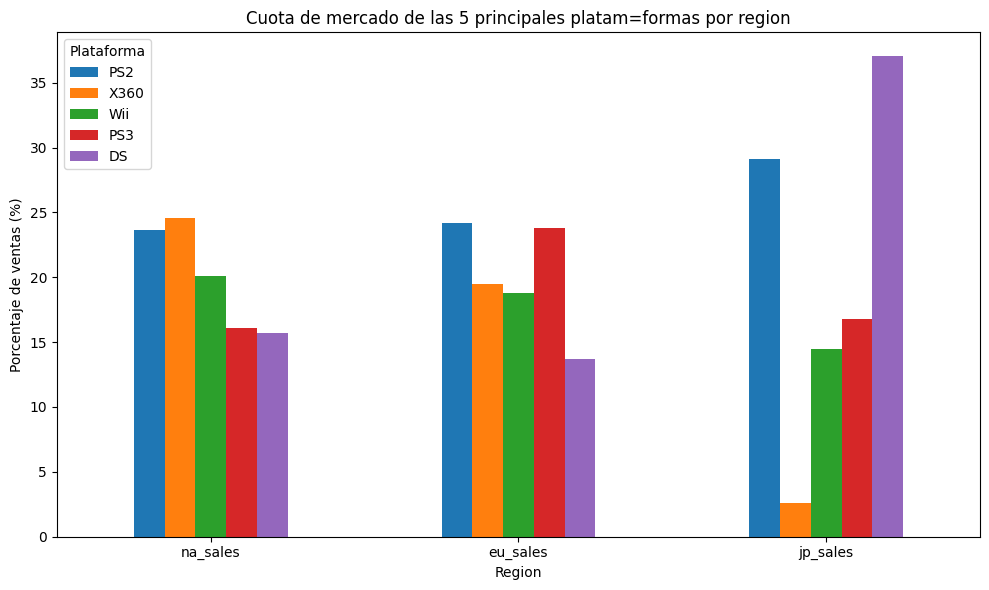

In [40]:
import matplotlib.pyplot as plt

part_per_region.T.plot(kind='bar', figsize=(10, 6))
plt.title('Cuota de mercado de las 5 principales platam=formas por region')
plt.ylabel('Porcentaje de ventas (%)')
plt.xlabel('Region')
plt.xticks(rotation=0)
plt.legend(title='Plataforma')
plt.tight_layout()
plt.show()


#Este grafico muestra que PS2 es el lider mundial aunque va en devacle por ausencia de nuevos lanzamientos y PS3, el unico que lo sobrepasa
#es DS en Japon. La plataforma de Wii tiene una presencia casi tan fuerte como PS2 en las tres regiones pero sufre lo mismo que el PS2.
#Estamos frente a un debacle de las plataformas de forma comun, por el comportamiento y presencia en todas las regiones, creo que el enfoque y la apuesta
#de promocionamiento seria PS3.

In [41]:
ventas_genero_region = (ice_games_2000.groupby('genre')[['na_sales', 'eu_sales', 'jp_sales']].sum())

ventas_genero_region['total'] = ventas_genero_region.sum(axis=1)
top5_generos = ventas_genero_region['total'].sort_values(ascending=False).head().index

#print(top5_generos)

top5_region_data = ventas_genero_region.loc[top5_generos].drop(columns='total')
participation_genre = top5_region_data.div(top5_region_data.sum(axis=0), axis=1)*100

print(participation_genre)

# 5 generos principales por region

               na_sales   eu_sales   jp_sales
genre                                        
Action        30.279014  32.120778  23.674646
Sports        23.723063  23.377714  13.585662
Shooter       19.933104  20.241226   4.168084
Role-Playing  11.362630  10.718170  43.276100
Misc          14.702189  13.542111  15.295508


#En la tabla superior observamos el porcentaje de ventas de cada genero a nivel global. El genero Action es el mas llamativo y estable, manteniendo una respetable porcion de mercado en todas las regiones.
#Luego el genero Sport posee estabilidad de mercado en la zona de Norte America y Europa junto con Shooter. Por su parte el Role-Playing
#es el mas fuerte en la zona de Japon. Estos puntales se deben a tendencias de cultura y el contenido consumido por los usuarios en areas distintas
a los juegos, como la television y el cine, en poco, la tendencia del consumo se puede ver marcado por el consumo online de streams y redes sociales que se encuentran en estado de emergentes.

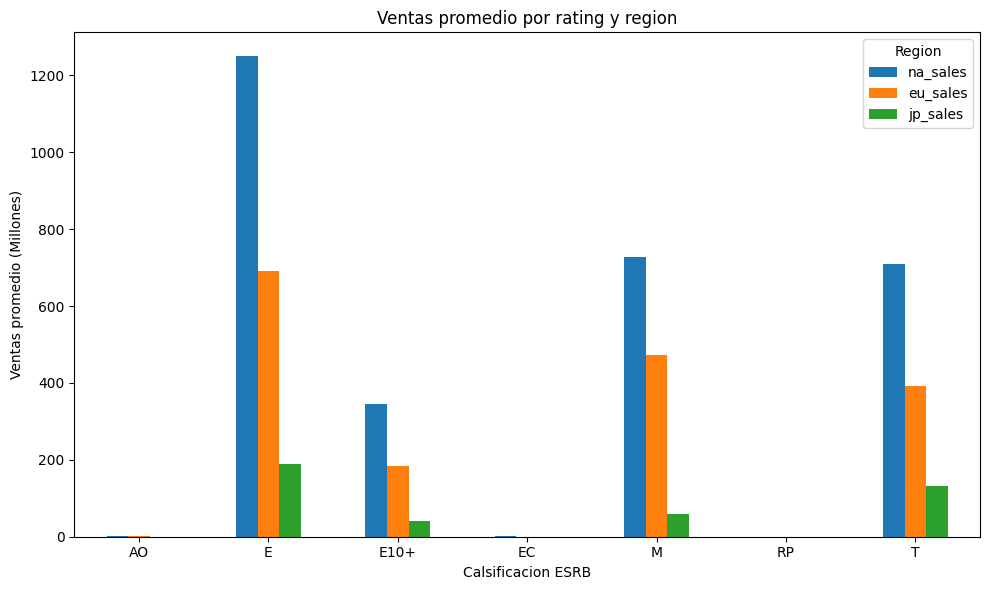

In [50]:
esrb_region = ice_games_2000.dropna(subset=['rating'])

sales_by_rating = (esrb_region.groupby('rating')[['na_sales', 'eu_sales', 'jp_sales']].sum().round(2))

import matplotlib.pyplot as plt

sales_by_rating.plot(kind='bar', figsize=(10,6))
plt.title('Ventas promedio por rating y region')
plt.ylabel('Ventas promedio (Millones)')
plt.xlabel('Calsificacion ESRB')
plt.xticks(rotation=0)
plt.legend(title='Region')
plt.tight_layout()
plt.show()

# Influencia de las clasificaciones rating(ESRB) sobre las regiones.

#Para concluir con los perfiles de usuarios analizados en este punto podemos concluir que:
#La plataforma con mayor perspectiva de estabilidad y/o crecimiento es PS3
#Los juegos que mas ventas tienen son accion, deportes(soccer), belicos(shooter) y los juegos de roles por ende las 
#promociones deberan estan enfocadas en esos juegos.
#Por ultimo las restricciones de los juegos son importantes en un tema de enfoque del tipo de publicidad que se usara
#debido a que la tendencia del mercado es que los gamers sean en una gran parte adultos que sobrepasan los 20 años.

#Ahora se procede a pruebas de hipotesis basadas en las calificaciones de los usuarios para Xbox(Accion) y PC(Deportes).

#alpha = 0.05 #Establesco este valor por que es el mas comun en estadistica.

#Hipotesis 1.
#Hn(nula): Los puntos promedio de usuarios para Xbox One y PC son iguales.
#Ha(alternativa): Los puntos promedio de los usuarios de Xbox One y PC son diferentes.

#Hipotesis 2.
#Hn(nula): Las calificaciones de usuarios para los generos Accion y Deportes son iguales.
#Ha(alternativa): Las calificaciones de usuarios para los generos Accion y Deportes son diferentes.    
#usare la prueba estadistica para dos medias independientes con la funcion ttest_ind de scipy.stats.

In [56]:
from scipy.stats import ttest_ind

#Filtrado Plataforma
xbox = ice_games_2000.query('platform == "XOne"')['user_score'].dropna()
pc = ice_games_2000.query('platform == "PC"')['user_score'].dropna()
t_stat1, pval1 = ttest_ind(xbox, pc, equal_var=False)
#Filtrado Genero
accion = ice_games_2000.query('genre == "Action"')['user_score'].dropna()
deportes = ice_games_2000.query('genre == "Sports"')['user_score'].dropna()
#Accion vs Deportes
t_stat2, pval2 = ttest_ind(accion, deportes, equal_var=False)

print(f'Xbox vs PC > p-valor: {pval1:.4f}')
print(f'Accion vs Deportes > p-valor: {pval2:.4f}')


Xbox vs PC > p-valor: 0.0000
Accion vs Deportes > p-valor: 0.1012


En el caso de Xbox y PC rechazamos la Hipotesis nula, ya que existe una diferencia significativa en las calificiones de usuarios entre Xbox One y PC.
Para las afecciones sobre los generos, aceptamos la Hipotesis nula ya que no hay evidencia suficiente para afirmar que los generos Accion y Deportes tienen calificaciones distintas segun los usuarios.

Conclusiones del proyecto 'PATRONES DE EXITO EN VIDEOJUEGOS'

El analisis se llevo a cabo sobre una base de datos abierta que abarca hasta el año 2016 desde su inicio. Se separo la muestra para tomar solo los datos a partir del 2000 ya que corresponden al 95% de las ventas.

Las observaciones mas importantes son:
- Hay dos plataformas dominantes que son distintas por region, por un lado USA y UE comparten su fidelidad con Play Station, mientras Japon esta dominada por DS (Nintendo). Probablemente se debe a la costumbre, origen y cultura de cada region y lo que ofrece cada plataforma.
- El genero de los juegos influye en su exito por region. Pero existe un comun denominador, Accion.

En cuanto a las calificacion. La de profesionales tienen una correlacion moderada respecto a las ventas, mientras que las de los usuarios no afectan. Por ende para las campañas publicitarias sera mas efectivo que los profesionales aparescan como influencers y recomienden.

Los generos para inversion segura por se altamente rentables son: Accion, deportes, belicos, juegos de roles y plataformas. La combinacion de titulos nuevos, combinando con estos generos y las plataformas adecuadas (juegos en plataformas distintas) segun la region son una estrategia solida de crecimiento.

Por ultimo, los juegos con rating 'E' son los que mas presencia tienen ya que son abiertos para todos, esa accesibilidad puede generar mayor consumo.


